<p style="font-size: 22px; font-weight: bold; margin: 0;">
  Alpaycan CABBAR 
</p>

<h1 style="text-align: center; margin-top: 0; font-size: 40px; font-weight: bold; margin-top: 0;">
  Image classification using neural network and convolutional neural network approaches 
</h1>

## Introduction
        This project focuses on image classification using the TinyImageNet100 dataset. The same dataset choice from Image Classification Using a Hand-Crafted Feature Approach project was used again in this project so that the results could be compared fairly. In this work, 15 classes were selected, and three main approaches were studied: a hand-crafted feature baseline from Project 1, a plain neural network, and a convolutional neural network. The aim was to examine how the choice of method affects classification performance on the same image dataset.

        Image classification is a key task in computer vision, allowing a model to assign an input image to the correct category. Traditional methods, like those based on SIFT, use features that are created by hand. In contrast, neural networks can automatically find important patterns in data. Convolutional neural networks are especially good at processing images because they can learn spatial features, such as edges, textures, and parts of objects, better than regular neural networks. Moreover, deeper residual models, such as ResNet, have shown to improve image recognition performance.

        In this project, I trained and evaluated both a standard neural network and a convolutional neural network (CNN) on the same chosen 15-class subset from TinyImageNet100. I compared their results to the best hand-crafted method from Image Classification Using a Hand-Crafted Feature Approach project. To ensure a fair comparison and reproducibility, I used the same dataset for both projects, which controlled the class selection process. After building a CNN from scratch, a stronger CNN model based on ResNet18 with transfer learning was also tested to improve performance. This allowed a clear comparison between traditional features, basic deep learning, and an improved deep learning approach.


In [1]:
import torch
import random
import pandas as pd
import torch.nn as nn
from PIL import Image
from pathlib import Path
from torchvision import models
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Phase 1: Dataset Preparation

        First, I set the dataset's location and then loaded all the class folders from TinyImageNet100. After that, I defined selected fifteen classes from the dataset, I am using a fixed classes to ensure the selection could be repeated. The same selection method was used in both projects to ensure a fair comparison.

        Then, I created two separate lists: one for training images and another for testing images. For each class, I gathered the file paths for all images. The first 400 images were then used for training, and the following 100 images were set aside for testing. After that, I recorded the location of each image, along with its class label. This process allowed the data to be used in later stages of the project.

In [2]:
dataset = Path.home() / "Desktop" / "CV- Assignment2-40507357" / "TinyImageNet100_2026" / "TinyImageNet100_2026"
classes = sorted([d for d in dataset.iterdir() if d.is_dir()])
print("Total classes found:", len(classes))

selected_class_names = [
    'n07734744', 'n04487081', 'n03902125', 'n04285008', 'n03424325',
    'n07753592', 'n03891332', 'n03976657', 'n09428293', 'n07615774',
    'n04328186', 'n03400231', 'n04067472', 'n07711569', 'n04146614'
]

selected_classes = [c for c in classes if c.name in selected_class_names]
selected_classes = sorted(selected_classes, key=lambda c: selected_class_names.index(c.name))

print("Selected classes are:", [c.name for c in selected_classes])
print("Number of classes:", len(selected_classes))

train_images = []
test_images = []

for class_dir in selected_classes:
    image_paths = sorted((class_dir / "images").glob("*.JPEG"))

    train_paths = image_paths[:400]
    test_paths  = image_paths[400:500]

    train_images.extend([(p, class_dir.name) for p in train_paths])
    test_images.extend([(p, class_dir.name) for p in test_paths])

train_images = sorted(train_images, key=lambda x: x[0].name)
test_images = sorted(test_images, key=lambda x: x[0].name)

print("Total training images:", len(train_images))
print("Total testing images:", len(test_images))

Total classes found: 100
Selected classes are: ['n07734744', 'n04487081', 'n03902125', 'n04285008', 'n03424325', 'n07753592', 'n03891332', 'n03976657', 'n09428293', 'n07615774', 'n04328186', 'n03400231', 'n04067472', 'n07711569', 'n04146614']
Number of classes: 15
Total training images: 6000
Total testing images: 1500


## Phase 2: Conducting image classification using the neural network approach 

        In Phase 2, I used a plain neural network for image classification. The main goal of this stage was to get the images ready for a neural network, build the model, train it, and then test it on the test set.

        To start, I made a dictionary called class_to_idx that changed the name of each class into a number. The neural network can't work with text class names directly, so I did this to make sure that each class had an integer value. Then I printed the dictionary to make sure that each class I had chosen had been given the right label.

In [3]:
class_to_idx = {class_name: i for i, class_name in enumerate(selected_class_names)}
print(class_to_idx)

{'n07734744': 0, 'n04487081': 1, 'n03902125': 2, 'n04285008': 3, 'n03424325': 4, 'n07753592': 5, 'n03891332': 6, 'n03976657': 7, 'n09428293': 8, 'n07615774': 9, 'n04328186': 10, 'n03400231': 11, 'n04067472': 12, 'n07711569': 13, 'n04146614': 14}


        I first made separate transforms for the training set and the test set. I resized the training images to 32 × 32, added random horizontal flips and small random rotations to make them more interesting, turned them into tensors, normalized them, and then flattened them into one long vector. I followed the same process for the test images: resizing, converting to tensors, normalizing, and flattening. I didn't include any additional steps, as I wanted the test data to remain unaltered.

        Then I made the TinyImageNetDataset class. I first stored the image list, the label dictionary, and the transform in this class. After that, the total number of images in the dataset was assigned to the __len__ method. Within __getitem__, a single image path and its corresponding class name were retrieved. After the image was opened in RGB format, the transformation was applied. Then, the class name was converted to its numerical label. Finally, the processed image and its label were returned.


In [4]:
train_transform_nn = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x.view(-1))
])

test_transform_nn = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x.view(-1))
])

class TinyImageNetDataset(Dataset):
    def __init__(self, image_list, class_to_idx, transform=None):
        self.image_list = image_list
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path, class_name = self.image_list[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label

        I created the training and testing dataset objects by using the image lists, the label dictionary, and the transforms I defined before. This prepared both datasets in a format that PyTorch could use. Then, I created the DataLoader for each dataset. I used a batch size of 32, shuffled the training data to improve learning, and kept the test data in fixed order for evaluation.

In [5]:
train_dataset = TinyImageNetDataset(train_images, class_to_idx, transform=train_transform_nn)
test_dataset = TinyImageNetDataset(test_images, class_to_idx, transform=test_transform_nn)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

        I defined the SimpleNN model for Phase 2. The input dimension was configured as 3 × 32 × 32, reflecting the resizing and flattening procedures applied to each image prior to its introduction into the network. Subsequently, I designed three fully connected layers, comprising 512, 256, and 128 units, which culminated in the final output layer, specifically designed for the 15 classification categories. Furthermore, to improve the stability of the training process and reduce the likelihood of overfitting, Batch Normalization, ReLU activation functions, and Dropout regularization were integrated between these layers.

In [6]:
class SimpleNN(nn.Module):
    def __init__(self, input_size=3*32*32, num_classes=15):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

        I selected the device to run the model on, using GPU if available, otherwise CPU, and moved the model to that device. After that, I defined CrossEntropyLoss as the loss function because this is a multi-class classification problem. Finally, I used the Adam optimizer with a learning rate of 0.0005 and weight_decay=1e-4 to update the model weights during training.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = SimpleNN(input_size=3*32*32, num_classes=15).to(device)
print(model_nn)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.0005, weight_decay=1e-4)

SimpleNN(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=15, bias=True)
  )
)


        I trained the neural network for 25 epochs. During each epoch, the model was set up for training, and the training images were processed by the network. Subsequently, the loss was computed, and the weights were adjusted via backpropagation and the designated optimizer. Simultaneously, the running loss was documented, and the number of correct predictions was tallied to determine the training accuracy for each epoch. Ultimately, the loss and accuracy metrics were preserved, and their values were printed following each epoch to facilitate monitoring of the training procedure.

In [8]:
num_epochs = 25

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model_nn.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_nn(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/25] - Loss: 2.5156, Accuracy: 18.08%
Epoch [2/25] - Loss: 2.3159, Accuracy: 24.55%
Epoch [3/25] - Loss: 2.2237, Accuracy: 27.20%
Epoch [4/25] - Loss: 2.1744, Accuracy: 28.63%
Epoch [5/25] - Loss: 2.1497, Accuracy: 29.88%
Epoch [6/25] - Loss: 2.1163, Accuracy: 31.72%
Epoch [7/25] - Loss: 2.0841, Accuracy: 31.85%
Epoch [8/25] - Loss: 2.0591, Accuracy: 32.77%
Epoch [9/25] - Loss: 2.0416, Accuracy: 33.88%
Epoch [10/25] - Loss: 2.0355, Accuracy: 34.30%
Epoch [11/25] - Loss: 2.0221, Accuracy: 33.73%
Epoch [12/25] - Loss: 2.0032, Accuracy: 34.57%
Epoch [13/25] - Loss: 1.9936, Accuracy: 34.97%
Epoch [14/25] - Loss: 1.9647, Accuracy: 35.70%
Epoch [15/25] - Loss: 1.9699, Accuracy: 36.28%
Epoch [16/25] - Loss: 1.9467, Accuracy: 36.45%
Epoch [17/25] - Loss: 1.9402, Accuracy: 37.37%
Epoch [18/25] - Loss: 1.9327, Accuracy: 36.37%
Epoch [19/25] - Loss: 1.9201, Accuracy: 37.53%
Epoch [20/25] - Loss: 1.9039, Accuracy: 38.02%
Epoch [21/25] - Loss: 1.9126, Accuracy: 36.87%
Epoch [22/25] - Loss: 

        I evaluated the trained neural network on the test set. I changed the model to evaluation mode and turned off gradient calculation because no learning was needed at this stage. Then, I passed the test images through the model, compared the predicted labels with the true labels, and calculated the final test accuracy of the plain neural network.

In [9]:
model_nn.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_nn(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy of the plain neural network: {test_accuracy:.2f}%")

Test Accuracy of the plain neural network: 40.80%


## Phase 3: Conducting image classification using the convolutional neural network approach 

        In Phase 3, I used the convolutional neural network approach for image classification. The goal of this phase was to get the images ready for a CNN, build the CNN model, train it, and then test it on the test set. A CNN can learn the features of an image while keeping the image's spatial structure. This makes it better for classifying images than a simple neural network.

        First, I used transforms to make different transforms for the training set and the test set. Compose lets you apply several image transformations one after the other. I resized the images in both sets to 64 × 64, turned them into tensors, and made them all the same size. I also added RandomHorizontalFlip and RandomRotation(10) as data augmentation steps to the training images to give the model more variety while it was learning. I didn't add any changes to the test transform because I wanted the test images to stay the same so that I could fairly evaluate them.


In [10]:
train_transform_cnn = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform_cnn = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

        I created the TinyImageNetDatasetCNN class for the CNN phase. In this class, I first stored the image list, label dictionary, and transform. Then, in __getitem__, I loaded each image, converted it to RGB format, applied the transform, changed the class name into its numerical label, and returned the image with its label.

In [11]:
class TinyImageNetDatasetCNN(Dataset):
    def __init__(self, image_list, class_to_idx, transform=None):
        self.image_list = image_list
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path, class_name = self.image_list[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[class_name]
        return image, label

        I created the training and testing dataset objects by using the image lists, label dictionary, and CNN transforms. After that, I created the DataLoader for both datasets with a batch size of 32. I shuffled the training data to help learning, while the test data was kept in fixed order for evaluation.


In [12]:
train_dataset_cnn = TinyImageNetDatasetCNN(train_images, class_to_idx, transform=train_transform_cnn)
test_dataset_cnn = TinyImageNetDatasetCNN(test_images, class_to_idx, transform=test_transform_cnn)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=32, shuffle=True)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=32, shuffle=False)

        I defined the SimpleCNN model for the CNN phase. First, I created the feature extraction part using three convolution layers, and each one was followed by ReLU and MaxPool2d. This allowed the model to learn image features while gradually reducing the image size. Then, I created the classifier part by flattening the feature maps and passing them through a fully connected layer, ReLU, Dropout, and the final output layer for the 15 classes.

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=15):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

        I selected the device to run the CNN on, using GPU if available, otherwise CPU, and moved the model to that device. After that, I defined CrossEntropyLoss as the loss function for multi-class classification. Finally, I used the Adam optimizer with a learning rate of 0.001 and weight_decay=1e-4 to update the CNN weights during training.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = SimpleCNN(num_classes=15).to(device)
print(model_cnn)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)

Using device: cuda
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=15, bias=True)
  )
)


        I trained the CNN for 25 epochs. In each epoch, I set the model to training mode, passed the training images through the network, calculated the loss, and updated the weights using backpropagation and the optimizer. At the same time, I recorded the running loss and counted the correct predictions to calculate training accuracy for each epoch. Finally, I saved the loss and accuracy values and printed them after every epoch to monitor the CNN training process.

In [15]:
num_epochs = 25

train_losses_cnn = []
train_accuracies_cnn = []

for epoch in range(num_epochs):
    model_cnn.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_cnn:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_cnn)
    epoch_acc = 100 * correct / total

    train_losses_cnn.append(epoch_loss)
    train_accuracies_cnn.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/25] - Loss: 2.4188, Accuracy: 18.78%
Epoch [2/25] - Loss: 2.0841, Accuracy: 32.35%
Epoch [3/25] - Loss: 1.9248, Accuracy: 37.35%
Epoch [4/25] - Loss: 1.8044, Accuracy: 41.53%
Epoch [5/25] - Loss: 1.6940, Accuracy: 44.78%
Epoch [6/25] - Loss: 1.6211, Accuracy: 47.42%
Epoch [7/25] - Loss: 1.5547, Accuracy: 49.95%
Epoch [8/25] - Loss: 1.5017, Accuracy: 51.70%
Epoch [9/25] - Loss: 1.4392, Accuracy: 53.70%
Epoch [10/25] - Loss: 1.3940, Accuracy: 55.17%
Epoch [11/25] - Loss: 1.3512, Accuracy: 56.47%
Epoch [12/25] - Loss: 1.3123, Accuracy: 57.13%
Epoch [13/25] - Loss: 1.2763, Accuracy: 59.05%
Epoch [14/25] - Loss: 1.2284, Accuracy: 60.00%
Epoch [15/25] - Loss: 1.1934, Accuracy: 60.93%
Epoch [16/25] - Loss: 1.1569, Accuracy: 62.45%
Epoch [17/25] - Loss: 1.1243, Accuracy: 62.68%
Epoch [18/25] - Loss: 1.1023, Accuracy: 64.18%
Epoch [19/25] - Loss: 1.0654, Accuracy: 65.03%
Epoch [20/25] - Loss: 1.0498, Accuracy: 65.63%
Epoch [21/25] - Loss: 1.0038, Accuracy: 65.80%
Epoch [22/25] - Loss: 

        I evaluated the simple CNN on the test set. First, I changed the model to evaluation mode and turned off gradient calculation because the model was no longer training. Then, I passed the test images through the CNN, compared the predicted labels with the true labels, and calculated the final test accuracy of the simple CNN.

In [16]:
model_cnn.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_cnn:
        images, labels = images.to(device), labels.to(device)

        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_cnn = 100 * correct / total
print(f"Test Accuracy of the simple CNN: {test_accuracy_cnn:.2f}%")

Test Accuracy of the simple CNN: 58.40%


        I prepared new transforms for the ResNet model. I resized the images to 224 × 224 because ResNet works with a larger input size than the simple CNN. For the training set, I also added random horizontal flip and small rotation for augmentation, then converted the images to tensors and normalized them using the standard mean and standard deviation values used for pretrained ResNet models. For the test set, I used the same resize and normalization steps but without augmentation.

In [17]:
train_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

        I created the training and testing dataset objects for ResNet by using the same CNN dataset class together with the new ResNet transforms. Then, I created the DataLoader for both datasets with a batch size of 32. The training data was shuffled to help learning, while the test data was kept in fixed order for evaluation.

In [18]:
train_dataset_resnet = TinyImageNetDatasetCNN(train_images, class_to_idx, transform=train_transform_resnet)
test_dataset_resnet = TinyImageNetDatasetCNN(test_images, class_to_idx, transform=test_transform_resnet)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=32, shuffle=False)

        Next, I loaded the ResNet18 model with pretrained weights. After that, I took the input size of the final fully connected layer and replaced the original output layer with a new one that produces 15 class outputs. Finally, I moved the model to the selected device so it was ready for training and evaluation.

In [19]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 15)

model_resnet = model_resnet.to(device)
print(model_resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

        I defined CrossEntropyLoss as the loss function because this is a multi-class classification problem. Then, I used the Adam optimizer with a learning rate of 0.0001 to update the ResNet model weights during training.

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)

        I trained the ResNet model for 15 epochs. In each epoch, I set the model to training mode, passed the training images through the network, calculated the loss, and updated the weights using backpropagation and the optimizer. I recorded the running loss and counted the correct predictions to calculate training accuracy for each epoch. Finally, I saved the loss and accuracy values and printed them after every epoch to monitor the training process.

In [21]:
num_epochs = 15

train_losses_resnet = []
train_accuracies_resnet = []

for epoch in range(num_epochs):
    model_resnet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_resnet(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_resnet)
    epoch_acc = 100 * correct / total

    train_losses_resnet.append(epoch_loss)
    train_accuracies_resnet.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/15] - Loss: 0.9535, Accuracy: 72.32%
Epoch [2/15] - Loss: 0.4362, Accuracy: 86.58%
Epoch [3/15] - Loss: 0.2684, Accuracy: 92.50%
Epoch [4/15] - Loss: 0.1745, Accuracy: 95.33%
Epoch [5/15] - Loss: 0.1221, Accuracy: 96.82%
Epoch [6/15] - Loss: 0.0887, Accuracy: 97.70%
Epoch [7/15] - Loss: 0.0631, Accuracy: 98.45%
Epoch [8/15] - Loss: 0.0571, Accuracy: 98.63%
Epoch [9/15] - Loss: 0.0425, Accuracy: 99.10%
Epoch [10/15] - Loss: 0.0488, Accuracy: 98.82%
Epoch [11/15] - Loss: 0.0393, Accuracy: 99.07%
Epoch [12/15] - Loss: 0.0443, Accuracy: 98.80%
Epoch [13/15] - Loss: 0.0430, Accuracy: 98.83%
Epoch [14/15] - Loss: 0.0313, Accuracy: 99.28%
Epoch [15/15] - Loss: 0.0304, Accuracy: 99.25%


        I evaluated the trained ResNet model on the test set. First, I changed the model to evaluation mode and turned off gradient calculation because the model was no longer learning. Then, I passed the test images through the model, compared the predicted labels with the true labels, and calculated the final test accuracy of ResNet18 with transfer learning.

In [22]:
model_resnet.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        outputs = model_resnet(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_resnet = 100 * correct / total
print(f"Test Accuracy of ResNet18 with transfer learning: {test_accuracy_resnet:.2f}%")

Test Accuracy of ResNet18 with transfer learning: 83.73%


        I printed the final test accuracies of the three main deep learning models: the plain neural network, the simple CNN, and ResNet18 with transfer learning. This gave a clear summary of the results and made it easier to compare the performance of each method.

In [23]:
print(f"Plain Neural Network Accuracy: {test_accuracy:.2f}%")
print(f"Simple CNN Accuracy: {test_accuracy_cnn:.2f}%")
print(f"ResNet18 Transfer Learning Accuracy: {test_accuracy_resnet:.2f}%")

Plain Neural Network Accuracy: 40.80%
Simple CNN Accuracy: 58.40%
ResNet18 Transfer Learning Accuracy: 83.73%


## Phase 4: Discussion and interpretation 

        In Phase 4, I compared the results of all methods and interpreted their performance. The main aim of this phase was to understand the differences between the hand-crafted feature methods, the plain neural network, the simple CNN, and the improved ResNet18 model. I also used this part to see which classes were predicted well and which classes were more difficult for the models.

        I created a function called plot_confusion_matrix to draw the confusion matrix for any trained model. Inside this function, I set the model to evaluation mode and turned off gradient calculation because the model was only being tested. Then, I passed all test images through the model and stored both the predicted labels and the true labels. After that, I used these values to create the confusion matrix. Finally, I displayed it as a plot so I could clearly see the correct predictions and the classes that were confused with each other.

In [24]:
def plot_confusion_matrix(model, data_loader, class_names, device, title="Confusion Matrix"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="viridis", xticks_rotation=90, values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.show()

        I created a results table to collect the final test accuracies of all models in one place. This table included the three methods from Project 1 together with the plain neural network, the simple CNN, and ResNet18 with transfer learning. I entered the Project 1 accuracies manually and used the saved test accuracy variables from Project 2 for the deep learning models. Finally, I converted the results into a pandas DataFrame and printed the table so that all methods could be compared clearly.

In [25]:
results = {
    "Method": [
        "A1: ORB + BoW + LinearSVC",
        "A1: SIFT + BoW + LinearSVC",
        "A1: Fisher Vector + LinearSVC",
        "Plain Neural Network",
        "Simple CNN",
        "ResNet18 + Transfer Learning"
    ],
    "Test Accuracy (%)": [
        7.26,
        22.00,
        22.93,
        round(test_accuracy, 2),
        round(test_accuracy_cnn, 2),
        round(test_accuracy_resnet, 2)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                          Method  Test Accuracy (%)
0      A1: ORB + BoW + LinearSVC               7.26
1     A1: SIFT + BoW + LinearSVC              22.00
2  A1: Fisher Vector + LinearSVC              22.93
3           Plain Neural Network              40.80
4                     Simple CNN              58.40
5   ResNet18 + Transfer Learning              83.73


        I selected the method names and their test accuracies from the results table. Then, I used a bar chart to visualise the performance of all classification methods in one figure. I also added labels for the x-axis and y-axis, set the title, and adjusted the x-axis text rotation so the method names could be read more clearly. Finally, I limited the y-axis from 0 to 100 and displayed the chart to make the comparison between the methods easier to understand.

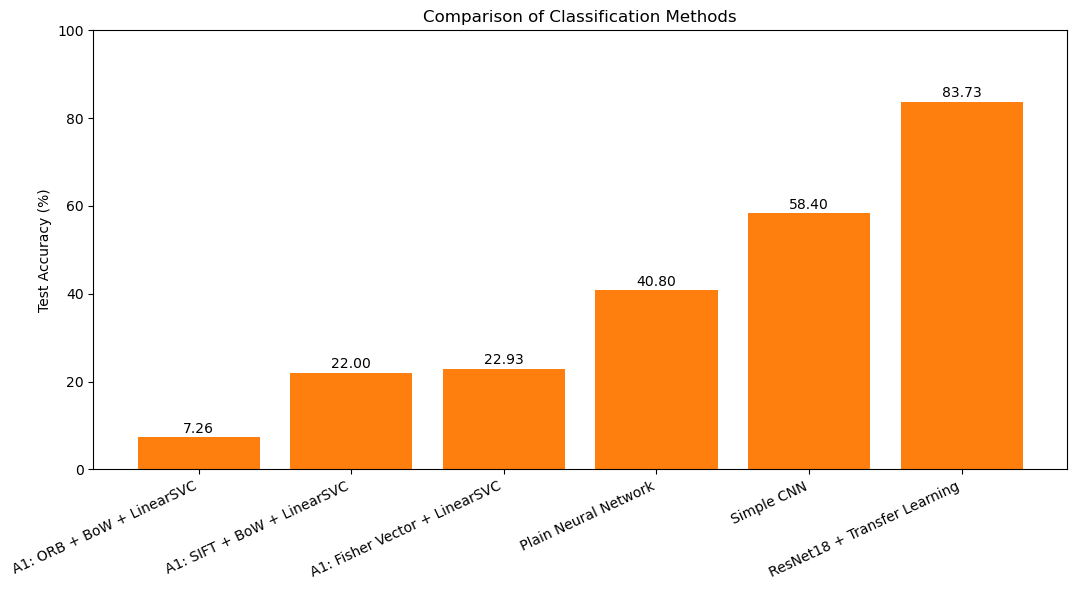

In [26]:
methods = results_df["Method"]
accuracies = results_df["Test Accuracy (%)"]

plt.figure(figsize=(11, 6))
bars = plt.bar(methods, accuracies)
plt.bar(methods, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Classification Methods")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

        I calculated the accuracy improvement between the main methods. First, I found the difference between the best Project 1 method and the plain neural network. Then, I calculated the improvement from the plain neural network to the simple CNN, and finally from the simple CNN to ResNet18 with transfer learning. This helped me measure how much performance increased at each stage.

In [27]:
a1_best = 22.93
a2_nn = round(test_accuracy, 2)
a2_cnn = round(test_accuracy_cnn, 2)
a2_resnet = round(test_accuracy_resnet, 2)

nn_gain = a2_nn - a1_best
cnn_gain = a2_cnn - a2_nn
resnet_gain = a2_resnet - a2_cnn

print(f"Improvement from Project 1 best method to Plain NN: {nn_gain:.2f}%")
print(f"Improvement from Plain NN to Simple CNN: {cnn_gain:.2f}%")
print(f"Improvement from Simple CNN to ResNet18 + Transfer Learning: {resnet_gain:.2f}%")

Improvement from Assignment 1 best method to Plain NN: 17.87%
Improvement from Plain NN to Simple CNN: 17.60%
Improvement from Simple CNN to ResNet18 + Transfer Learning: 25.33%


        I plotted these improvement values as a bar chart. This made it easier to see how much the accuracy increased from one method to the next and which stage gave the largest improvement.

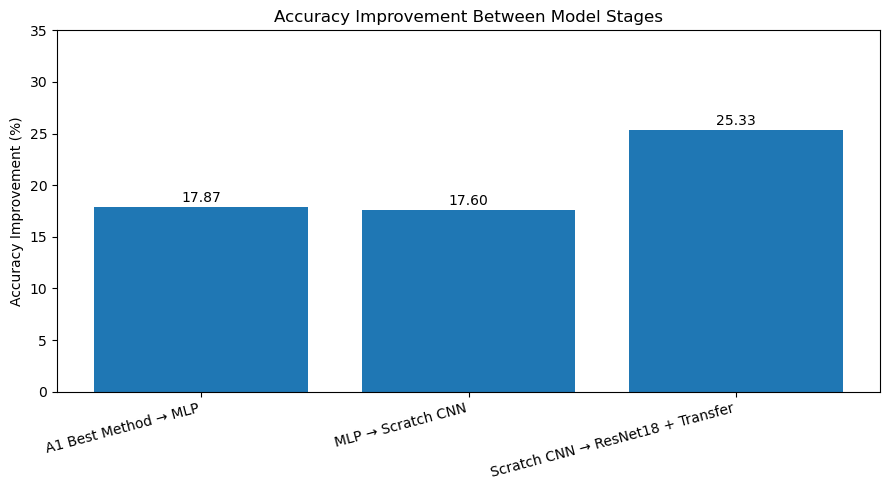

In [31]:
a1_best = 22.93
mlp_acc = round(test_accuracy, 2)
cnn_acc = round(test_accuracy_cnn, 2)
resnet_acc = round(test_accuracy_resnet, 2)

improvement_labels = [
    "A1 Best Method → MLP",
    "MLP → Scratch CNN",
    "Scratch CNN → ResNet18 + Transfer"
]

improvement_values = [
    mlp_acc - a1_best,
    cnn_acc - mlp_acc,
    resnet_acc - cnn_acc
]


plt.figure(figsize=(9, 5))
bars = plt.bar(improvement_labels, improvement_values)

plt.ylabel("Accuracy Improvement (%)")
plt.title("Accuracy Improvement Between Model Stages")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 35)

for bar, value in zip(bars, improvement_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

        I found the best and worst methods from the results table. I did this by selecting the method with the highest test accuracy and the method with the lowest test accuracy. Finally, I printed both results to clearly show which approach performed the best and which one performed the weakest.

In [32]:
best_method = results_df.loc[results_df["Test Accuracy (%)"].idxmax()]
worst_method = results_df.loc[results_df["Test Accuracy (%)"].idxmin()]

print("Best method:")
print(best_method)

print("\nWorst method:")
print(worst_method)

Best method:
Method               ResNet18 + Transfer Learning
Test Accuracy (%)                           83.73
Name: 5, dtype: object

Worst method:
Method               A1: ORB + BoW + LinearSVC
Test Accuracy (%)                         7.26
Name: 0, dtype: object


        I plotted the confusion matrix for the plain neural network by using the test data. This allowed me to see how well the model predicted each class, not only the overall accuracy. From the confusion matrix, I could see that some classes had stronger correct predictions on the main diagonal, while other classes were confused with similar classes more often. This helped me understand where the plain neural network performed well and where it still had weaknesses.

<Figure size 1000x1000 with 0 Axes>

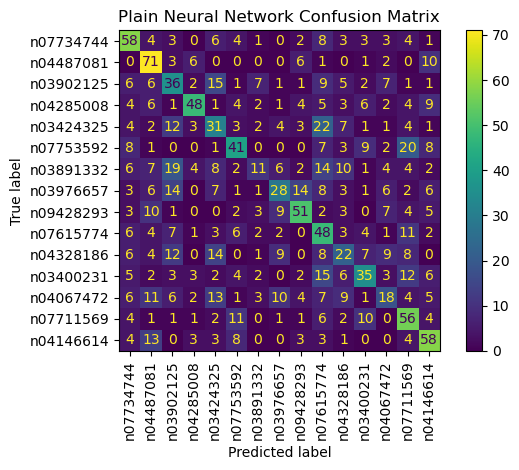

In [33]:
plot_confusion_matrix(
    model=model_nn,
    data_loader=test_loader,
    class_names=selected_class_names,
    device=device,
    title="Plain Neural Network Confusion Matrix"
)

        I plotted the confusion matrix for the simple CNN by using the test data. This helped me see the class-level performance of the CNN in more detail, instead of looking only at the overall test accuracy. From the confusion matrix, I could see that the simple CNN had a stronger main diagonal than the plain neural network, which means it predicted more classes correctly. However, there were still some classes that were confused with others, so the model improved the results but was not perfect yet.

<Figure size 1000x1000 with 0 Axes>

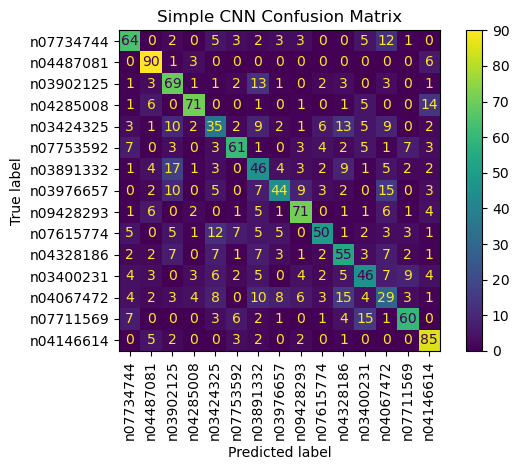

In [34]:
plot_confusion_matrix(
    model=model_cnn,
    data_loader=test_loader_cnn,
    class_names=selected_class_names,
    device=device,
    title="Simple CNN Confusion Matrix"
)

        I plotted the confusion matrix for ResNet18 by using the test data. This gave a detailed view of how the improved CNN performed on each class, not only the final overall accuracy. From the confusion matrix, I could see that ResNet18 had the strongest main diagonal among all models, which means it predicted most classes correctly. There were fewer wrong predictions compared with the plain neural network and the simple CNN, so this confirmed that ResNet18 with transfer learning gave the best performance in this project.

<Figure size 1000x1000 with 0 Axes>

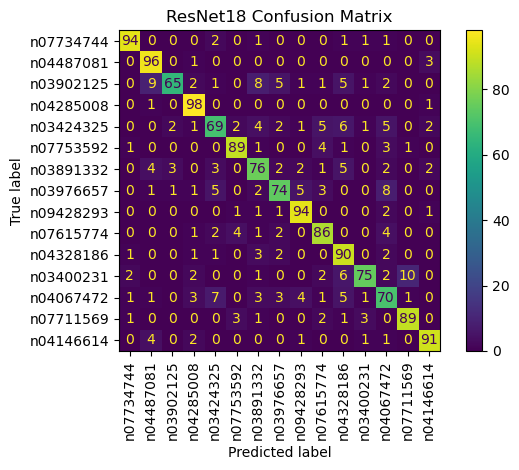

In [35]:
plot_confusion_matrix(
    model=model_resnet,
    data_loader=test_loader_resnet,
    class_names=selected_class_names,
    device=device,
    title="ResNet18 Confusion Matrix"
)

        Finally, I saved the trained models as checkpoint files so they could be reused later. For each model, I stored the model name, the learned weights using state_dict(), and the final test accuracy. This was done for the plain neural network, the simple CNN, and ResNet18 with transfer learning. Saving the checkpoints makes it possible to load the trained models again and reproduce the reported results more easily.

In [37]:
torch.save({
    "model_name": "SimpleNN",
    "model_state_dict": model_nn.state_dict(),
    "test_accuracy": test_accuracy,
}, "model_nn_checkpoint.pth")

torch.save({
    "model_name": "SimpleCNN",
    "model_state_dict": model_cnn.state_dict(),
    "test_accuracy": test_accuracy_cnn,
}, "model_cnn_checkpoint.pth")

torch.save({
    "model_name": "ResNet18",
    "model_state_dict": model_resnet.state_dict(),
    "test_accuracy": test_accuracy_resnet,
}, "model_resnet_checkpoint.pth")

print("Checkpoints saved successfully.")

Checkpoints saved successfully.


## References

- https://realpython.com/python-ai-neural-network/
- https://github.com/matlab-deep-learning/resnet-18
- https://link.springer.com/chapter/10.1007/978-3-642-15561-1_11
- https://home.cse.ust.hk/~qyang/Docs/2009/tkde_transfer_learning.pdf
- https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
- https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html
- https://www.datacamp.com/tutorial/pytorch-tutorial-building-a-simple-neural-network-from-scratch
- https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf
- https://debayanmitra1993.medium.com/explainable-convolution-neural-networks-training-resnet-18-from-scratch-on-imagenet-200-dataset-3c745d3f1a98